In [1]:
%load_ext watermark


In [2]:
import itertools as it
import os

import matplotlib as mpl
from matplotlib import pyplot as plt
import pandas as pd
from phyloframe import _auxlib as pfa
from phyloframe import legacy as pfl
from pyfonts import load_google_font
import seaborn as sns
from teeplot import teeplot as tp

import pylib


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  warnings.warn(


In [3]:
%watermark -diwmuv -iv


Last updated: 2026-03-18T02:54:34.404337+00:00

Python implementation: CPython
Python version       : 3.11.15
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

seaborn   : 0.13.2
matplotlib: 3.10.0
phyloframe: 0.2.2
pandas    : 2.2.3
pylib     : 0.0.0
teeplot   : 1.4.2

Watermark: 2.4.3



In [4]:
teeplot_subdir = os.environ.get("NOTEBOOK_NAME", "2026-03-12-btr-clade")
teeplot_subdir


'2026-03-12-btr-clade'

In [5]:
pfa.seed_random(1)


In [6]:
font = load_google_font("Merriweather", weight=300)
mpl.font_manager.fontManager.addfont(font.get_file())
plt.rcParams["font.family"] = font.get_name()


## Prep Data


In [7]:
df_pure = pfl.alifestd_join_roots(
    pd.read_parquet("https://osf.io/vjhgs/download"),
)
df_pure


,id,dstream_data_id,ancestor_id,dstream_rank,hstrat_differentia_bitwidth,dstream_S,data_hex,bookend_left,bookend_right,bookend_value,...,CEREBRASLIB_HSTRAT_DSTREAM_ALGO_NAME,ASYNC_GA_GENOME_FLAVOR,is_extant,layer,layer_T,position,origin_time,hstrat_rank,is_root,is_oldest_root
0,0,NaN,0,NaN,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,True,True
1,1,NaN,0,NaN,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False,False
2,2,NaN,0,190.0,1.0,96.0,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,94.0,94.0,False,False
3,3,NaN,2,382.0,1.0,96.0,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,286.0,286.0,False,False
4,4,NaN,3,574.0,1.0,96.0,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,478.0,478.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99967,99967,1.009251e+09,98534,76091.0,1.0,96.0,bfb55c1e04a4f29ed05252d84bd80b3ad6a627d1,38682658.0,38682658.0,38682658.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingonly,False,1247.0,11297.0,151104.0,75995.0,75995.0,False,False
99968,99968,1.009495e+09,97878,76091.0,1.0,96.0,bfb5e23304a4f0f3d05252d81fd0f33f98b78d92,101105698.0,101105698.0,101105698.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingonly,False,1247.0,11297.0,394944.0,75995.0,75995.0,False,False
99969,99969,1.009207e+09,99869,76092.0,1.0,96.0,bfb5a2fa04a4f467d05252d84bd80b3a9c269853,27290658.0,27290658.0,27290658.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingonly,False,1247.0,11297.0,106604.0,75996.0,75996.0,False,False
99970,99970,1.009227e+09,99713,76093.0,1.0,96.0,bfb503e404a4f8c7d04253d84ad8ca3a7f468ed1,32388386.0,32388386.0,32388386.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingonly,False,1247.0,11297.0,126517.0,75997.0,75997.0,False,False


In [8]:
df_pure["x"] = df_pure["position"] // df_pure["nCol"]
df_pure["x_"] = df_pure["x"] / df_pure["nRow"]
df_pure["y"] = df_pure["position"] % df_pure["nCol"]
df_pure["y_"] = df_pure["y"] / df_pure["nCol"]

df_pure["origin_time"] = df_pure["dstream_rank"]


## Plot Layer Tree


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars} or set HSTRAT_ALIFESTD_WARN_TOPOLOGICAL_SENSITIVITY_SUPPRESS environment variable.
  warnings.warn(
/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/phyloframe/legacy/_alifestd_warn_topological_sensitivity.py:35: UserWarning: alifestd_prune_extinct_lineages_asexual performs delete operations that do not update topology-dependent columns, which may be invalidated: ['num_leaves']. Use `origin_time` to recalculate branch lengths for collapsed phylogeny. To silence this warning, use alifestd_drop_topological_sensitivity{_polars

teeplots/2026-03-12-btr-clade/layout=vertical+regime=pure+seed=5+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-12-btr-clade/layout=vertical+regime=pure+seed=5+viz=draw-ctree+x=x+y=y+ext=.png


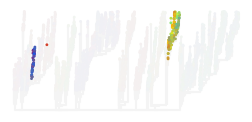

teeplots/2026-03-12-btr-clade/cmap=bcyr+regime=pure+seed=5+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-12-btr-clade/cmap=bcyr+regime=pure+seed=5+viz=draw-cscatter+x=x+y=y+ext=.png


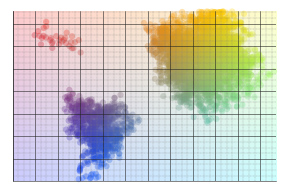

In [9]:
for regime, seed in it.product(
    ("pure",),
    (5,),
):
    df = df_pure.copy()
    df_ = df.copy()
    df1 = pfl.alifestd_downsample_tips_clade_asexual(
        df,
        n_downsample=3_000,
        seed=seed,
    )

    df2 = pfl.alifestd_downsample_tips_clade_asexual(
        df,
        n_downsample=200,
        seed=seed + 8,
    )

    df3 = pfl.alifestd_downsample_tips_clade_asexual(
        df,
        n_downsample=1_000,
        seed=seed + 5,
    )

    df_ = pfl.alifestd_downsample_tips_asexual(
        df_,
        n_downsample=3_000,
        seed=seed,
    )
    df_["x__"] = df_["x_"].copy()
    df_["y__"] = df_["y_"].copy()

    mask = (
        df_["id"].isin(df1["id"])
        | df_["id"].isin(df2["id"])
        | df_["id"].isin(df3["id"])
    )
    df_.loc[~mask, "x_"] = pd.NA
    df_.loc[~mask, "y_"] = pd.NA


    df_ = pfl.alifestd_collapse_unifurcations(df_)
    df1 = pfl.alifestd_collapse_unifurcations(df1)
    df2 = pfl.alifestd_collapse_unifurcations(df2)
    df3 = pfl.alifestd_collapse_unifurcations(df3)

    for layout in "vertical",:

        with tp.teed(
            pylib.chloropleth.draw_ctree,
            df_,
            x="x__",
            y="y__",
            cmap=lambda *args, **kwargs: sns.set_hls_values(
                pylib.cmap.bcyr.get_color(*args, **kwargs),
                l=0.95,
                s=0.2,
            ),
            layout=layout,
            scatter_kws=dict(
                # alpha=0.3,
                edgecolor="none",
                s=4,
            ),
            scatter_shuffle=1,
            tree_kws=dict(
                edge=dict(
                    color="#f4f4f4",
                    linewidth=0.5,
                ),
                margins=-0.05,
            ),
            teeplot_outattrs={"regime": regime, "seed": seed},
            teeplot_subdir=teeplot_subdir,
        ) as teed:
            pylib.chloropleth.draw_ctree(
                df_,
                x="x_",
                y="y_",
                cmap=pylib.cmap.bcyr.get_color,
                layout=layout,
                scatter_kws=dict(
                    edgecolor="none",
                    s=4,
                ),
                scatter_shuffle=1,
                tree_kws=dict(
                    edge=dict(
                        alpha=0.0,
                        color="#f4f4f4",
                        linewidth=0.5,
                    ),
                    margins=-0.05,
                ),
            )
            teed.invert_yaxis()
            teed.figure.set_size_inches(3, 1.33)

    with tp.teed(
        pylib.chloropleth.draw_cscatter,
        pd.concat(
            [df1, df2, df3],
        ).dropna(subset=["x_", "y_"]),
        x="x",
        y="y",
        cmap=pylib.cmap.bcyr.get_color,
        despine=True,
        major=100,
        minor=25,
        xmax=1170,
        ymax=755,
        scatter_kws=dict(
            s=20,
        ),
        teeplot_outattrs={"cmap": "bcyr", "regime": regime, "seed": seed},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_aspect("equal")
        fig = teed.figure
        fig.set_size_inches(3, 2)
        fig.tight_layout()
